<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Introduction
This project builds a classification model to predict whether a tumor is **benign** or **malignant** using the Breast Cancer Wisconsin dataset from the UCI Machine Learning Repository (available through sklearn).

Following the full machine learning workflow:
- Data loading and preprocessing  
- Exploratory Data Analysis (EDA)  
- Training two classification models  
- Evaluating model performance  
- Interpreting results  
- Discussing deployment and monitoring strategies   

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Check missing values
X.isnull().sum()
# Check duplicates
X.duplicated().sum()

np.int64(0)

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

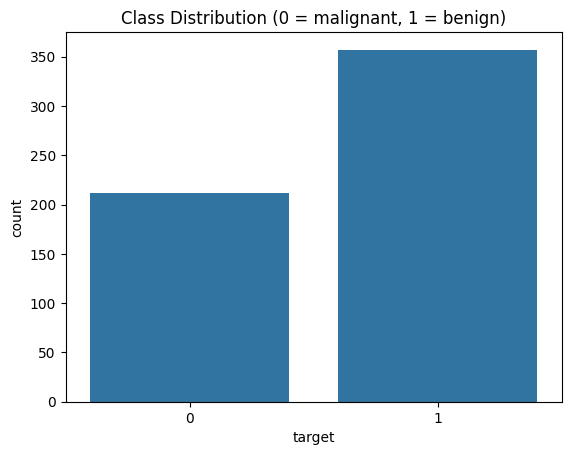

In [6]:
# Class distribution
sns.countplot(x=y)
plt.title("Class Distribution (0 = malignant, 1 = benign)")
plt.show()

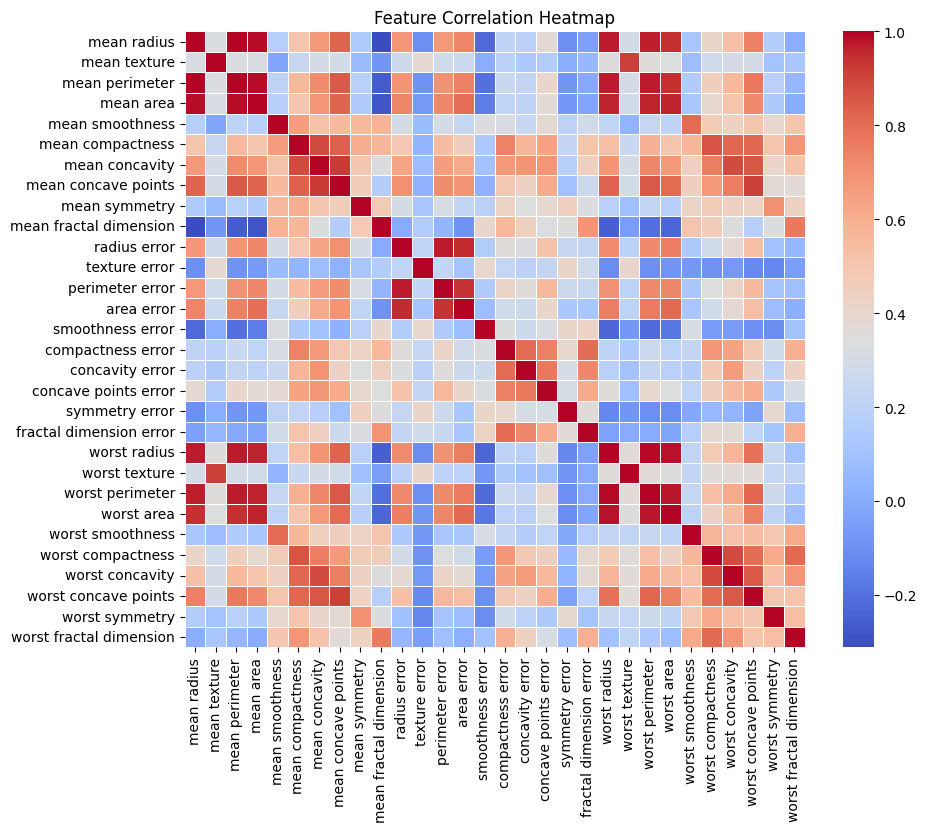

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

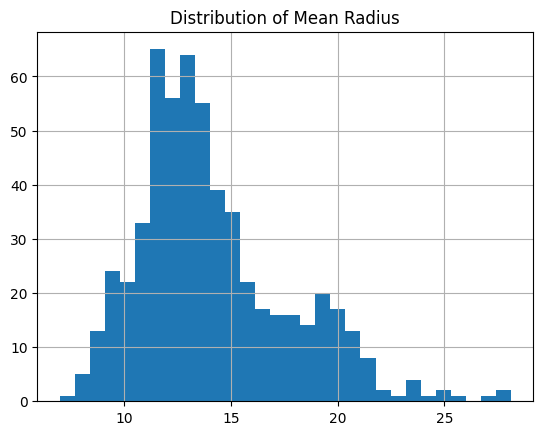

In [8]:
# Example feature distribution
X["mean radius"].hist(bins=30)
plt.title("Distribution of Mean Radius")
plt.show()

In [9]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"=== {name} ===")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
    print()

    return y_pred, y_prob

log_pred, log_prob = evaluate(log_reg, X_test_scaled, y_test, "Logistic Regression")
rf_pred, rf_prob = evaluate(rf, X_test, y_test, "Random Forest")

=== Logistic Regression ===
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1-score : 0.9861111111111112
ROC-AUC  : 0.9953703703703703

=== Random Forest ===
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1-score : 0.9655172413793104
ROC-AUC  : 0.9937169312169312



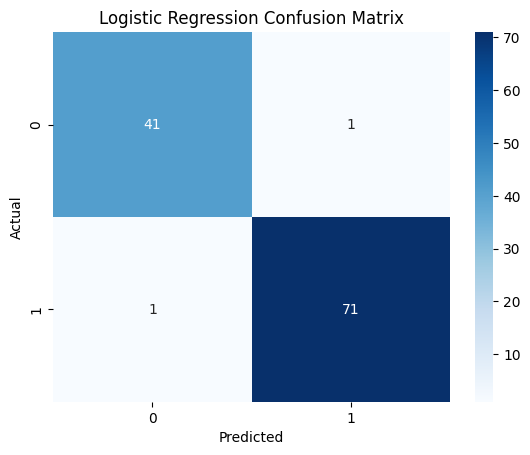

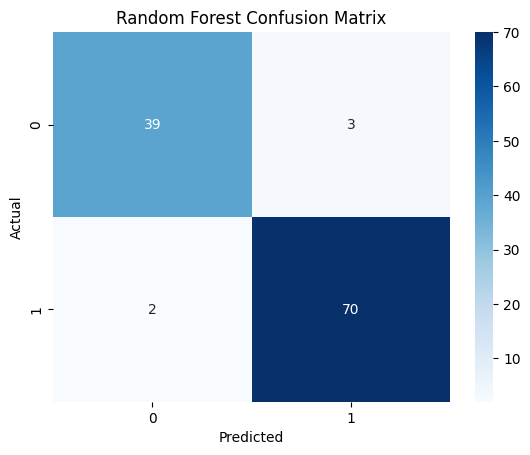

In [11]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, log_pred, "Logistic Regression Confusion Matrix")
plot_cm(y_test, rf_pred, "Random Forest Confusion Matrix")

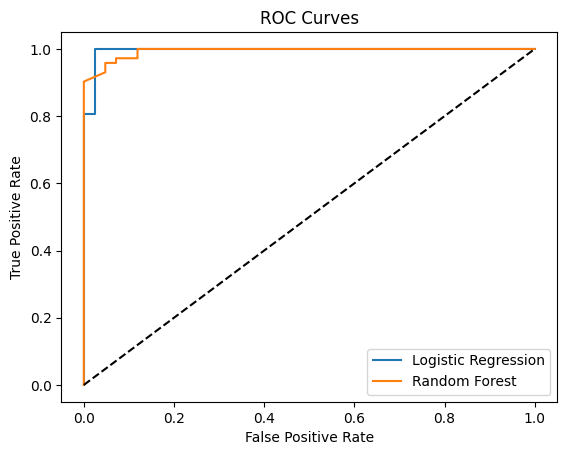

In [12]:
# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

 Deployment Strategy
The best-performing model can be deployed using:
- A Flask or FastAPI web service
- A cloud platform like AWS, Azure, or Google Cloud
- A simple REST API endpoint `/predict`

Incoming data would be sent as JSON and the model returns a prediction.

Monitoring Strategy
To maintain performance:
- Track prediction accuracy over time
- Detect data drift (changes in input patterns)
- Retrain the model regularly with new data
- Log errors and unusual inputs

Conclusion
This project demonstrated the full workflow of building a classification model.  
Random Forest performed best overall, showing higher accuracy and ROC-AUC.  
The dataset was clean and easy to work with, and the models were able to distinguish between benign and malignant tumors effectively.